# InSight Seismic Data (VBB)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from obspy.signal.detrend import polynomial
from obspy import read, read_inventory
from obspy.signal.rotate import rotate2zne
from obspy.signal.filter import bandpass
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import warnings
warnings.simplefilter('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 5

In [2]:
path_dataless='./instrumental_resp/dataless.XB.ELYSE.seed';
fdsn_client = Client("IRIS")
net_code = "XB" # Fill in the two-character network code for InSight
sta_code = "ELYSE"
Date_s=20220504;
out_csv='./'+str(Date_s)+'_ACC_original.csv'
# Origin time of S1222a (2022-05-04-23:23:07, Kawamura et al., 2022)
starttime = UTCDateTime("2021-12-24T22:40:00") 
endtime = UTCDateTime("2021-12-24T23:15:00")
down_sp=20; #down to X Hz

## Download data

In [3]:
st_U = read(r"D:\大三下学期课程\行星固体物理\Homework\HW6\insan-2026-04-09\sol 1094\data products\seis\xb.elyse.02.bhu.2021.358.*.mseed")
st_V = read(r"D:\大三下学期课程\行星固体物理\Homework\HW6\insan-2026-04-09\sol 1094\data products\seis\xb.elyse.02.bhv.2021.358.*.mseed")
st_W = read(r"D:\大三下学期课程\行星固体物理\Homework\HW6\insan-2026-04-09\sol 1094\data products\seis\xb.elyse.02.bhw.2021.358.*.mseed")
## Time-series
st_U = st_U.slice(starttime, endtime)
st_V = st_V.slice(starttime, endtime)
st_W = st_W.slice(starttime, endtime)

## Detrend

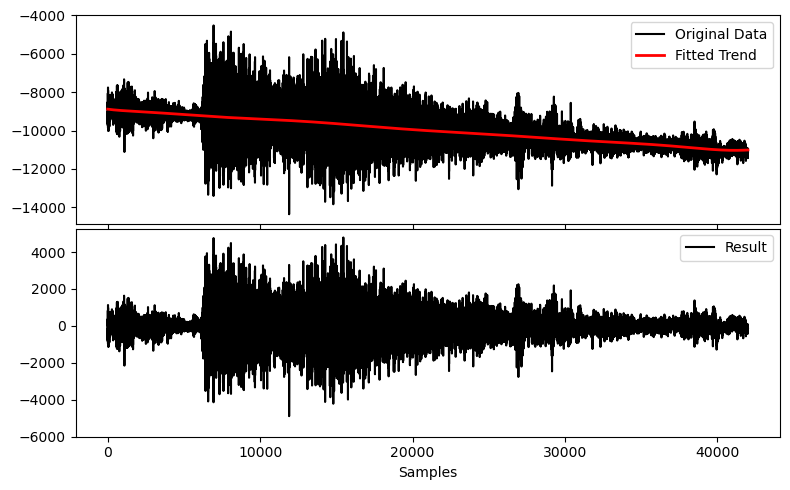

In [4]:
st_U[0].data=polynomial(st_U[0].data, order=12, plot=True)  
st_V[0].data=polynomial(st_V[0].data, order=12, plot=False)  
st_W[0].data=polynomial(st_W[0].data, order=12, plot=False)  

## Remove instrumental response

In [5]:
inv=read_inventory(path_dataless);
pre_filt = [0.003, 0.005, 9.5, 10];
st_U[0].remove_response(inventory=inv,output="VEL", pre_filt=pre_filt, zero_mean=True,taper=True,taper_fraction=0.05)
st_V[0].remove_response(inventory=inv,output="VEL", pre_filt=pre_filt, zero_mean=True,taper=True,taper_fraction=0.05)
st_W[0].remove_response(inventory=inv,output="VEL", pre_filt=pre_filt, zero_mean=True,taper=True,taper_fraction=0.05)
t_vbb = np.linspace(0, st_U[0].data.size/st_U[0].stats.sampling_rate, st_U[0].data.size)

## Rotation (UVW => ZNE)

In [6]:
U_azi =inv.select(channel=st_U[0].stats.channel, station=st_U[0].stats.station)[0][0][0].azimuth
U_dip =inv.select(channel=st_U[0].stats.channel, station=st_U[0].stats.station)[0][0][0].dip
V_azi =inv.select(channel=st_V[0].stats.channel, station=st_V[0].stats.station)[0][0][0].azimuth
V_dip =inv.select(channel=st_V[0].stats.channel, station=st_V[0].stats.station)[0][0][0].dip
W_azi =inv.select(channel=st_W[0].stats.channel, station=st_W[0].stats.station)[0][0][0].azimuth
W_dip =inv.select(channel=st_W[0].stats.channel, station=st_W[0].stats.station)[0][0][0].dip
print("U azimuth =" ,U_azi); print("U dip =" ,U_dip)
print("V azimuth =" ,V_azi); print("V dip =" ,V_dip)
print("W azimuth =" ,W_azi); print("W dip =" ,W_dip)
print(st_U[0].data.size); print(st_V[0].data.size); print(st_W[0].data.size);
Z, N, E=rotate2zne(st_U[0].data, U_azi, U_dip, st_V[0].data, V_azi, V_dip, st_W[0].data, W_azi, W_dip)

U azimuth = 135.1
U dip = -29.4
V azimuth = 15.0
V dip = -29.2
W azimuth = 255.0
W dip = -29.7
42001
42001
42001


## Bandpass filter

In [7]:
from obspy.signal.filter import envelope

bands = {
    "1-5s": (1/5, 1/1),
    "8-15s": (1/15, 1/8),
    "6-9s": (1/9, 1/6),
    "9-12s": (1/12, 1/9),
    "12-15s": (1/15, 1/12),
}

components = {
    "Z": Z,
    "N": N,
    "E": E
}

results = {}

for comp_name, tr in components.items():
    results[comp_name] = {}

    for band_name, (fmin, fmax) in bands.items():
        tr_filt = tr.copy()
        tr_filt = bandpass(tr_filt, fmin, fmax, st_U[0].stats.sampling_rate, corners=4, zerophase=True)

        results[comp_name][band_name] = tr_filt

In [8]:
env_bands = ["6-9s", "9-12s", "12-15s"]

envelopes = {}

for comp in results:
    envelopes[comp] = {}

    for band in env_bands:
        data = results[comp][band]
        env = envelope(data)
        envelopes[comp][band] = env

## Plot

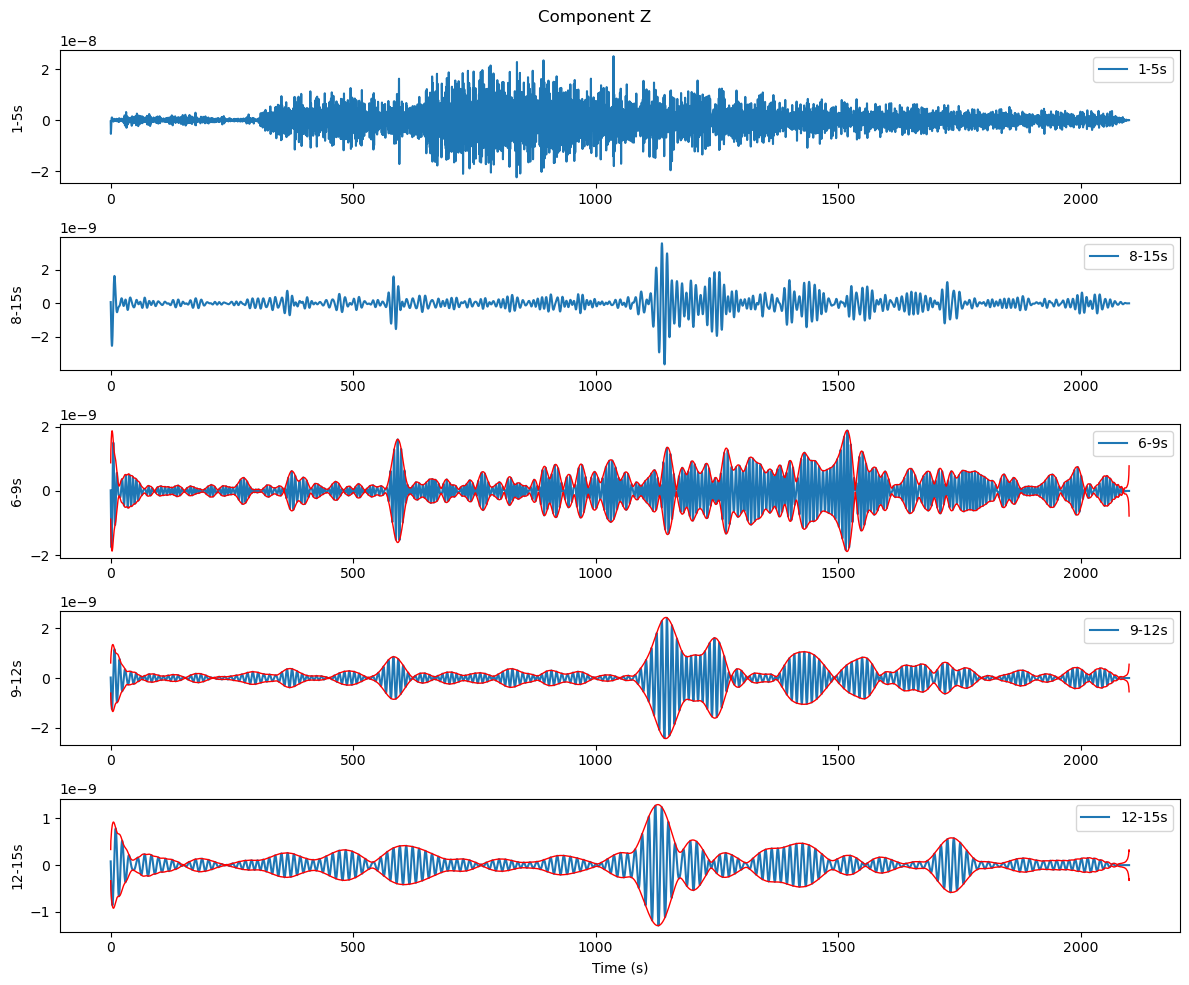

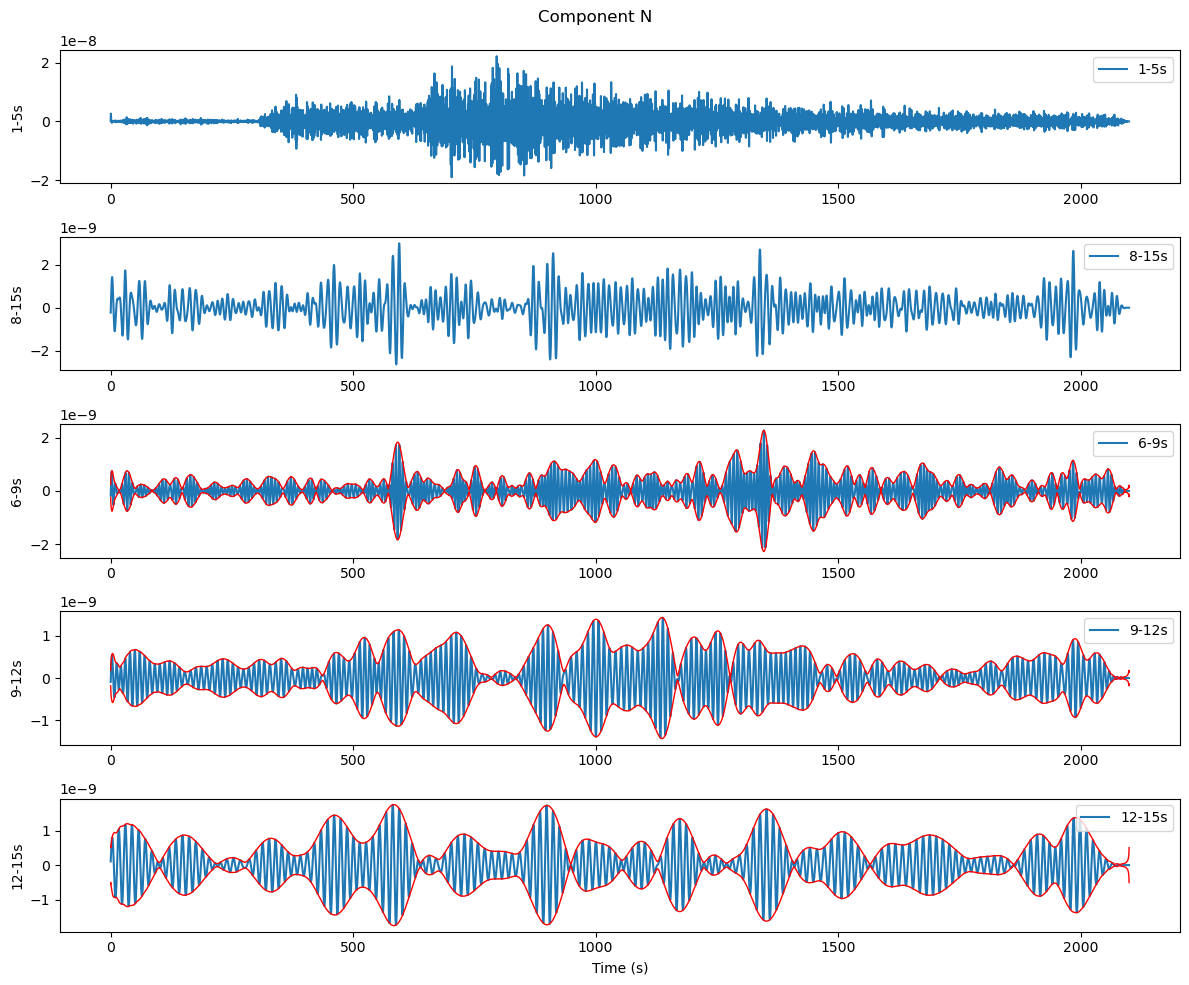

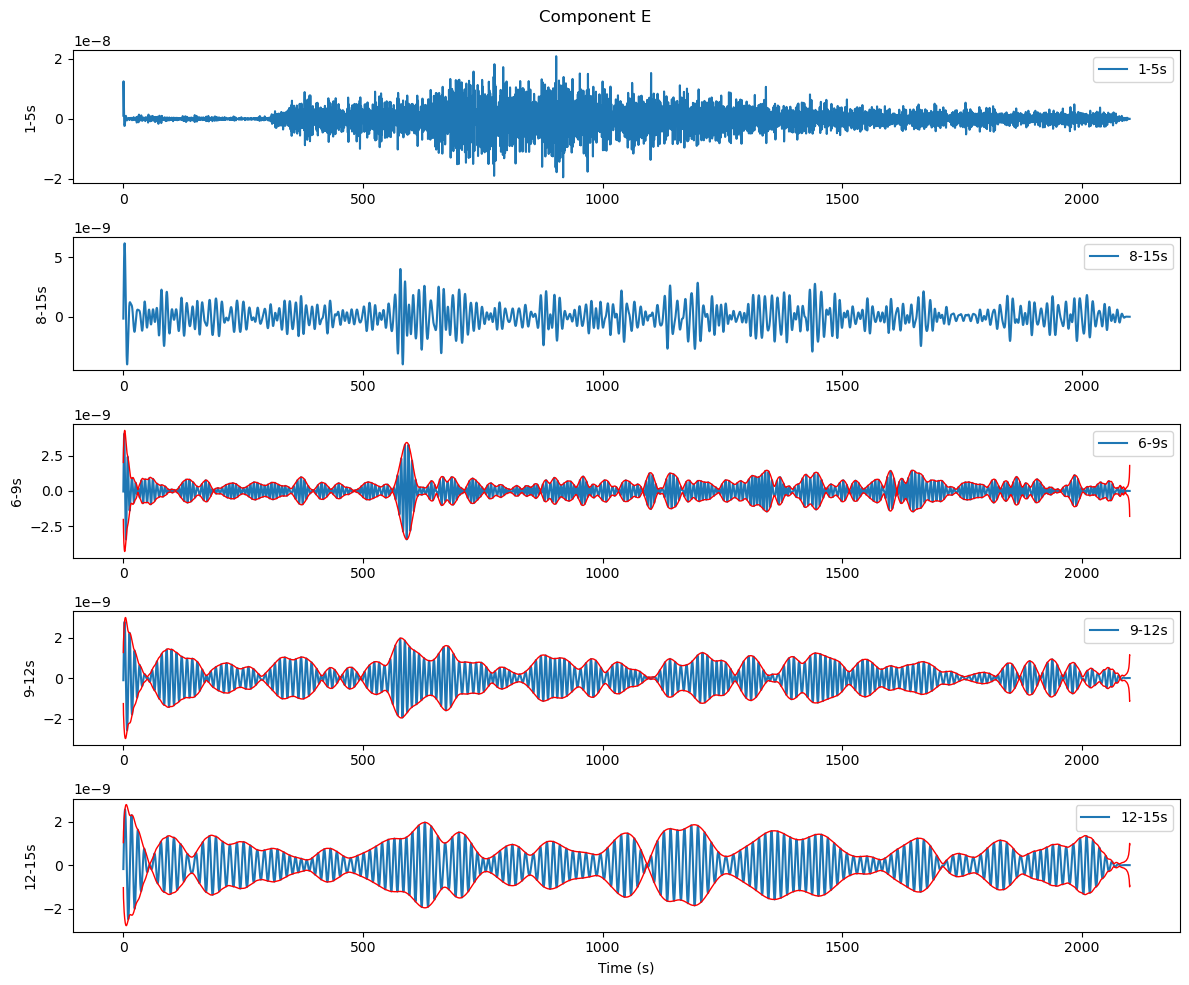

In [9]:
df = st_U[0].stats.sampling_rate

for comp in results:
    plt.figure(figsize=(12, 10))
    plt.suptitle(f"Component {comp}")

    i = 1
    for band in bands:
        tr = results[comp][band]
        t = np.arange(len(tr)) / df

        plt.subplot(len(bands), 1, i)
        plt.plot(t, tr, label=band)

        # 叠加包络
        if band in env_bands:
            plt.plot(t, envelopes[comp][band], 'r', linewidth=1)
            plt.plot(t, -envelopes[comp][band], 'r', linewidth=1)

        plt.ylabel(band)
        plt.legend(loc="upper right")
        i += 1

    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()